In [ ]:
import os

BASE_DIR = "ABSOLUTE_PATH_TO_PROJECT_ROOT"
DATA_DIR = os.path.join(BASE_DIR, "data")
CODE_DIR = os.path.join(BASE_DIR, "code")
FC_DIR = os.path.join(BASE_DIR, "models_save/fc")
UC_DIR = os.path.join(BASE_DIR, "models_save/uc")

import sys

sys.path.append(CODE_DIR)

import os
import json
import math
from collections import defaultdict
from typing import Tuple, Optional, Sequence

import numpy as np
import pandas as pd

from matplotlib import pyplot as plt
import matplotlib.gridspec as grid_spec

import torch
from torch import Tensor, nn

from tqdm.auto import tqdm

from scipy.sparse import issparse
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.metrics.pairwise import pairwise_kernels
from sklearn.utils import check_array, check_X_y
from sklearn.utils.validation import check_is_fitted

from loader.generator import DataGenerator, ChronoSplittedTsDataset
from config import TSDataConfig, TaskConfig
from main_utils import _init_fc
from omegaconf import DictConfig

from models.forcast.darts import SimpleDartsModel
from models.forcast.forcast_service import ForcastService
from models.forcast.forcast_base import FCPredictionData
from models.uncertainty.uc_service import UncertaintyService
from models.uncertainty.dist_match.tree import DistMatchQRF
from utils.calc_torch import calc_residuals

The StatsForecast module could not be imported. To enable support for the AutoARIMA, AutoETS and Croston models, please consider installing it.


In [2]:
TASK_CONFIG = DictConfig(
    {
        "task_type": "PI",
        "alpha": 0.1,
        "data_splits": [0.6, 0.15, 0.25],
        "fc_estimator_mode": "single",
        "global_norm": False,
        "add_config": None,
    }
)


def load_dataset(data_config: TSDataConfig, task_config: TaskConfig = None):
    task_config = task_config or TaskConfig(**TASK_CONFIG)
    return DataGenerator.get_data(
        data_config=data_config,
        task_config=TASK_CONFIG,
        replace_base_dir=DATA_DIR,
        X_norm_param=None,
        Y_norm_param=None,
        hydro_static_norm_param=None,
    )


def load_forecast_service(
    fc_model=None, model_config=None, data_config=None, task_config=None
):
    if fc_model is None:
        fc_model = SimpleDartsModel
        model_config = dict(
            model="darts-forest", model_params={"lags": 50, "lags_past_covariates": 50}
        )

    task_config = task_config or TASK_CONFIG

    return ForcastService(
        int_fc_model=lambda: fc_model(**model_config),
        task_config=task_config,
        model_config=model_config,
        data_config=data_config,
        persist_dir=FC_DIR,
    )

In [14]:
def get_residuals(forcast_service: ForcastService, data, is_calib: bool = False) -> Tuple[np.ndarray, np.ndarray]:
    data = forcast_service.prepare([data], forcast_service._task_config.alpha)[0]

    if is_calib:
        calib_data = UncertaintyService._map_to_calib_data(data)
        fc_result = forcast_service.predict(
            FCPredictionData(
                ts_id=calib_data.ts_id,
                X_past=calib_data.X_pre_calib,
                Y_past=calib_data.Y_pre_calib,
                X_step=calib_data.X_calib,
                step_offset=calib_data.step_offset,
            )
        )
        return calc_residuals(Y_hat=fc_result.point, Y=calib_data.Y_calib).numpy(), fc_result.point

    fc_result = forcast_service.predict(
        FCPredictionData(
            ts_id=data.ts_id,
            X_past=data.X_calib,
            Y_past=data.Y_calib,
            X_step=data.X_test,
            step_offset=data.test_step,
        )
    )
    return calc_residuals(Y_hat=fc_result.point, Y=data.Y_test).numpy(), fc_result.point


def patch_data(
    data: np.ndarray,
    patch_len: int,
) -> np.ndarray:
    return np.lib.stride_tricks.sliding_window_view(data, patch_len)


def get_residuals_dataset(
    forcast_service: ForcastService,
    data: ChronoSplittedTsDataset,
    patch_len: int,
    is_calib: bool = False,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    residuals, preds = get_residuals(forcast_service, data, is_calib)
    residuals = np.ravel(residuals)
    patches = patch_data(residuals, patch_len)
    inputs = patches[:-1]
    targets = patches[1:, -1]
    return inputs, targets, preds[patch_len:]

In [28]:
def epanechnikov_kernel(u: Tensor):
    zeros = torch.zeros_like(u)
    return (0.75 * (1 - u.pow(2))).where(abs(u) <= 1, zeros)


def compute_kernel(kernel_fn: callable, u: Tensor, h: float, p: int) -> Tensor:
    u_norm = u.norm(p=2, dim=-1, keepdim=True)
    return kernel_fn(u_norm / h) / math.pow(h, p)


def compute_data_relationship(
    target: Tensor,
    data: Tensor,
    lbd: Tensor,
    kernel_fn: callable,
    bandwidth: float,
    n_channels: int = 1,
) -> Tuple[Tensor, Tensor]:
    diff = data - target
    kernel = compute_kernel(kernel_fn, diff, bandwidth, n_channels)
    relationship = 1 + lbd * diff[..., :1] * kernel
    return relationship, kernel


def compute_lambda_loss(
    target: Tensor,
    data: Tensor,
    lbd: Tensor,
    kernel_fn: callable,
    bandwidth: float,
    n_channels: int = 1,
):
    data_relationship, _ = compute_data_relationship(
        target, data, lbd, kernel_fn, bandwidth, n_channels
    )
    loss = -data_relationship.log().sum()

    return loss


def get_optimal_lambda(
    target: Tensor,
    data: Tensor,
    kernel_fn: callable,
    bandwidth: float = 1.0,
    n_channels: int = 1,
    lr: float = 1e-1,
    patience: int = 3,
    n_epochs: int = 200,
):
    lbd = nn.Parameter(torch.tensor(1.0))
    opt = torch.optim.Adam([lbd], lr)

    best_loss = np.inf
    best_lbd = 0.0
    cur_patience = patience

    for _ in range(n_epochs):
        opt.zero_grad()
        loss = compute_lambda_loss(target, data, lbd, kernel_fn, bandwidth, n_channels)
        loss.backward()
        opt.step()
        loss_item = loss.item()
        lbd_item = lbd.item()

        if loss_item < best_loss:
            best_loss = loss_item
            cur_patience = patience
            best_lbd = lbd_item
        else:
            cur_patience -= 1

        # print(
        #     f"[{cur_patience}/{patience}] Loss: {loss:.6f}; Lambda: {lbd_item:.6f} {best_lbd:.6f}"
        # )
        if cur_patience <= 0:
            break
            

    return best_lbd


def get_adj_weights(
    target: Tensor,
    data: Tensor,
    lbd: float,
    kernel_fn: callable,
    bandwidth: float,
    n_channels: int,
) -> Tensor:
    data_relationship, kernel = compute_data_relationship(
        target, data, lbd, kernel_fn, bandwidth, n_channels
    )
    probabilities = 1 / (len(data) * data_relationship)
    weights = probabilities * kernel
    weights = weights / weights.sum()
    return weights


def get_quantiles(weights, ys, alphas):
    sorted_idx = torch.argsort(ys)
    sorted_ys = ys[sorted_idx]
    sorted_weights = weights[sorted_idx]
    cumsum = torch.cumsum(sorted_weights, dim=0)
    
    quantiles = []
    for alpha in alphas:
        idx = torch.argmax((cumsum >= alpha).float())
        quantiles.append(sorted_ys[idx])
    return torch.tensor(quantiles)


def get_bounds(quantiles: np.ndarray) -> np.ndarray:
    n_quantiles = len(quantiles)
    n_ids = n_quantiles // 2
    upper_ids = list(range(n_ids))
    lower_ids = list(range(n_quantiles - n_ids, n_quantiles))
    widths = quantiles[upper_ids] - quantiles[lower_ids]
    min_width_id = np.argmin(widths)
    return np.array(
        [quantiles[upper_ids[min_width_id]], quantiles[lower_ids[min_width_id]]]
    )


def test_kowcpi(
    data: ChronoSplittedTsDataset,
    forecast_service: ForcastService,
    alphas: Sequence[float],
    patch_len: int = 10,
    lbd_kwargs: Optional[dict] = None,
): 
    lbd_kwargs = lbd_kwargs if lbd_kwargs is not None else {}
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    calib_xs, calib_ys, calib_points = get_residuals_dataset(
        forecast_service, data, patch_len, is_calib=True
    )
    test_xs, test_ys, test_points = get_residuals_dataset(
        forecast_service, data, patch_len, is_calib=True
    )
    test_bounds = []

    kernel_fn = epanechnikov_kernel
    bandwidth = 40
    n_channels = patch_len
    alphas = torch.tensor(alphas).double().to(device)

    res_history = calib_xs, calib_ys
    for t, test_patch in enumerate(tqdm(test_xs)):
        test_tensor = torch.from_numpy(test_patch).double().to(device).unsqueeze(0)
        res_x_tensor, res_y_tensor = (
            torch.from_numpy(res_arr).double().to(device) for res_arr in res_history
        )

        lbd = get_optimal_lambda(
            test_tensor, res_x_tensor, kernel_fn, bandwidth, n_channels, **lbd_kwargs
        )
        adj_weights = get_adj_weights(
            test_tensor, res_x_tensor, lbd, kernel_fn, bandwidth, n_channels
        )
        quantiles = get_quantiles(adj_weights.squeeze(-1), res_y_tensor, alphas)
        quantiles = quantiles.cpu().numpy()
        bounds = get_bounds(quantiles)

        test_point = test_points[t].item()
        test_bounds.append(bounds + test_point)

        res_history = [
            np.concatenate([res_data, [test_datum]])
            for res_data, test_datum in zip(res_history, [test_xs[t], test_ys[t]])
        ]
    test_bounds = np.stack(test_bounds)
    return test_ys, test_points, test_bounds

In [29]:
def plot_regions(gt: np.ndarray, preds: np.ndarray, bounds: np.ndarray):
    fig, ax = plt.subplots(figsize=(10, 6))
    n_items = len(gt)
    xs = np.arange(0, n_items)

    ax.plot(gt, label="GT")
    ax.plot(preds, label="Preds")

    ax.fill_between(
        xs, bounds[:, 0], bounds[:, 1], alpha=0.7, color="#EC8305"
    )
    fig.legend()

    return fig

8750


`predict()` was called with `n > output_chunk_length`: using auto-regression to forecast the values after `output_chunk_length` points. The model will access `(n - output_chunk_length)` future values of your `past_covariates` (relative to the first predicted time step). To hide this warning, set `show_warnings=False`.


  0%|          | 0/1212 [00:00<?, ?it/s]

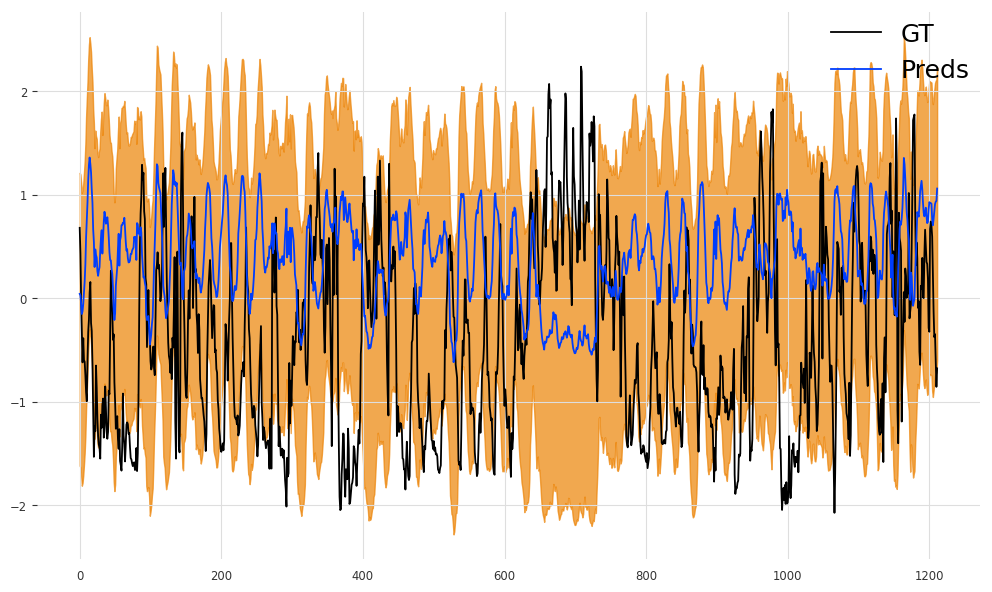

In [ ]:
PATCH_LEN = 100
ALPHAS = [0.9, 0.95, 0.0, 0.05]
TREE_DIR = os.path.join(BASE_DIR, "models_save/uc/")
DATA_MAP = {
    "Elec": (
        "electric",
        ["/some_base_dir/data/enbPI/electricity-normalized.csv"],
        0,
    ),
    "Solar": (
        "solar",
        ["/some_base_dir/data/enbPI/Solar_Atl_data_aligned.csv"],
        0,
    ),
    "Wind": (
        "wind",
        ["/some_base_dir/data/enbPI/Wind_Hackberry_Generation_2019_2020.csv"],
        0,
    ),
    "NFLX": (
        "qrf_ks_error_normal_stockNFLX_darts-forest|100.pkl",
        "darts_forest_dist_match_stock_nflx_s30_170725_142303",
        "stockNFLX",
        0,
    ),
}

for data_type, (datatype, data_paths, file_idx) in DATA_MAP.items():
    data_config = DictConfig(
        {"dataset_type": datatype, "paths": data_paths, "add_config": None}
    )
    datasets = load_dataset(TSDataConfig(**data_config))
    forcast_service = load_forecast_service(data_config=data_config)
    test_ys, test_preds, test_bounds = test_kowcpi(
        datasets[file_idx],
        forcast_service,
        ALPHAS,
        PATCH_LEN,
    )
    fig = plot_regions(test_ys, test_preds, test_bounds)
    fig.tight_layout()
    fig.show()